# 🛍️ Task 2: Customer Segmentation Using Unsupervised Learning

## Problem Statement
A mall wants to understand its customers better. By analyzing **age, annual income, and spending score**, we can group customers into meaningful segments and create **targeted marketing strategies** for each group.

## Objective
- Apply K-Means Clustering to segment mall customers
- Use PCA and t-SNE to visualize high-dimensional clusters
- Propose marketing strategies for each customer segment

## Dataset
**Mall Customers Dataset** — Kaggle  
Source: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

---
## ⬇️ How to Get the Dataset

**Option A (Recommended — Kaggle API):**
1. Go to: https://www.kaggle.com/settings → Account → API → Create New Token
2. A `kaggle.json` file will be downloaded
3. Upload it to Colab and run the cells below

**Option B (Manual):**
1. Download `Mall_Customers.csv` from the Kaggle link above
2. Upload it directly to Colab using the file upload cell below

In [2]:
# ── OPTION B: Manual Upload ───────────────────────────────────────────────────
# Run this cell if you want to upload Mall_Customers.csv manually

from google.colab import files
import os

if not os.path.exists('Mall_Customers.csv'):
    print('Please upload Mall_Customers.csv')
    uploaded = files.upload()
else:
    print('✅ Mall_Customers.csv already exists')

✅ Mall_Customers.csv already exists


## Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Cluster colors and names (will be filled after clustering)
CLUSTER_COLORS = ['#4361ee', '#f77f00', '#2dc653', '#e63946', '#7b2d8b']

print('✅ Libraries loaded')

✅ Libraries loaded


## Step 2: Load Dataset

In [4]:
df = pd.read_csv('Mall_Customers.csv')

# Rename columns for clarity
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Missing values:\n{df.isnull().sum()}')
df.head(10)

Dataset shape: (200, 5)
Columns: ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']
Missing values:
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## Step 3: Exploratory Data Analysis (EDA)

In [5]:
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,CustomerID,Age,Annual_Income,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


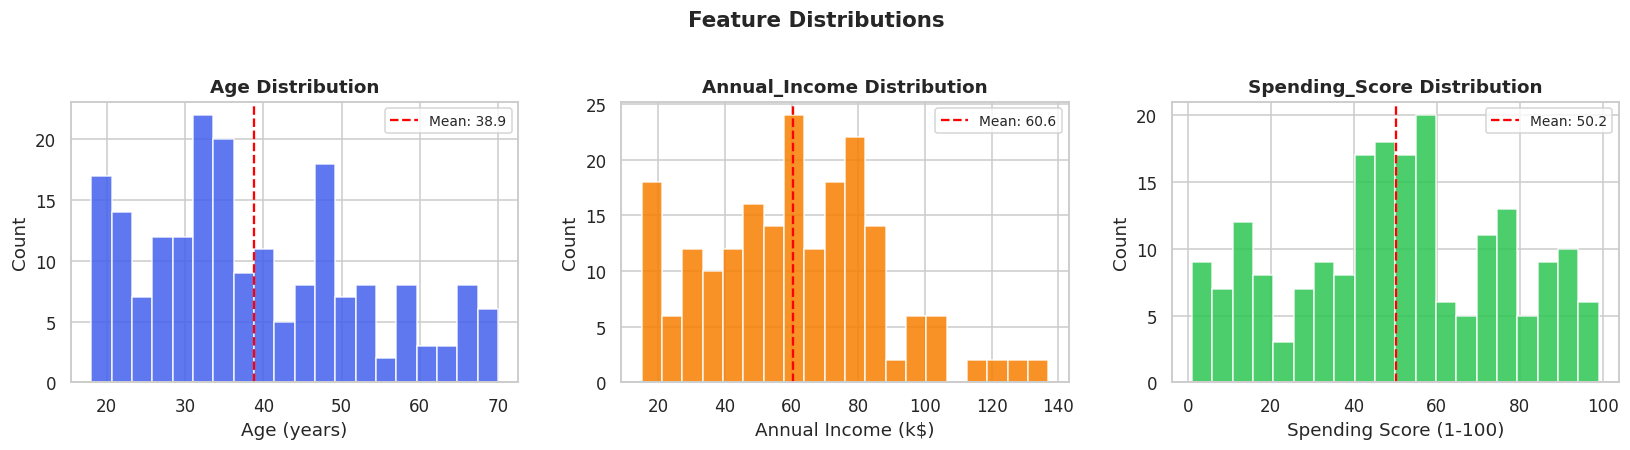

In [8]:
# ── Distribution plots for all numeric features ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = ['Age', 'Annual_Income', 'Spending_Score']
colors   = ['#4361ee', '#f77f00', '#2dc653']
xlabels  = ['Age (years)', 'Annual Income (k$)', 'Spending Score (1-100)']

for ax, feat, color, xlabel in zip(axes, features, colors, xlabels):
    ax.hist(df[feat], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[feat].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[feat].mean():.1f}')
    ax.set_title(f'{feat} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

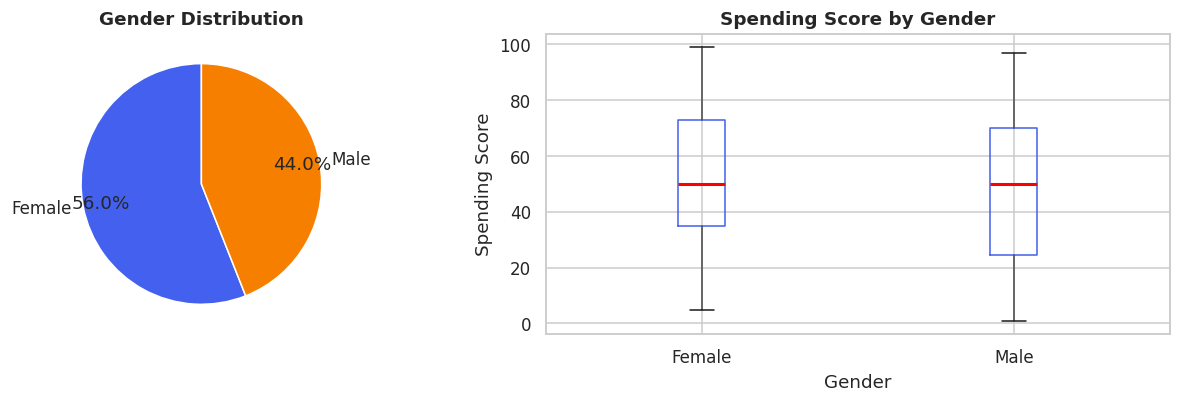

In [9]:
# ── Gender breakdown ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gender pie chart
gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#4361ee', '#f77f00'],
            startangle=90, pctdistance=0.85)
axes[0].set_title('Gender Distribution', fontsize=12, fontweight='bold')

# Spending Score by Gender
df.boxplot(column='Spending_Score', by='Gender', ax=axes[1],
           boxprops=dict(color='#4361ee'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Spending Score by Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Spending Score')
plt.suptitle('')

plt.tight_layout()
plt.show()

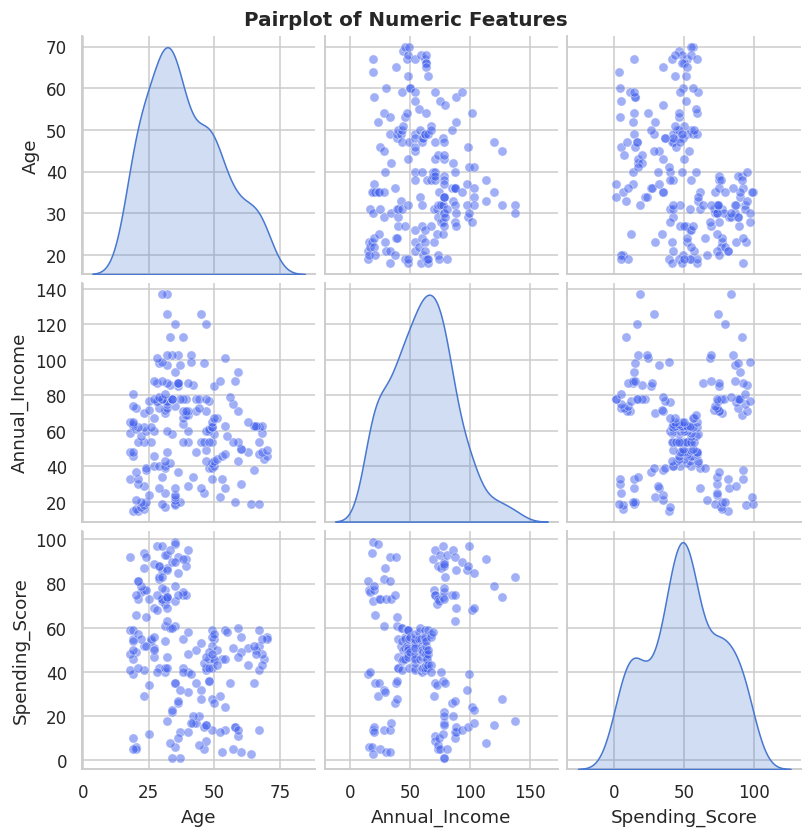

In [10]:
# ── Pairplot to see relationships between features ────────────────────────────
sns.pairplot(df[['Age', 'Annual_Income', 'Spending_Score']],
             diag_kind='kde', plot_kws={'alpha': 0.5, 'color': '#4361ee'})
plt.suptitle('Pairplot of Numeric Features', fontsize=13, fontweight='bold', y=1.01)
plt.show()

## Step 4: Find Optimal Number of Clusters — Elbow Method + Silhouette Score

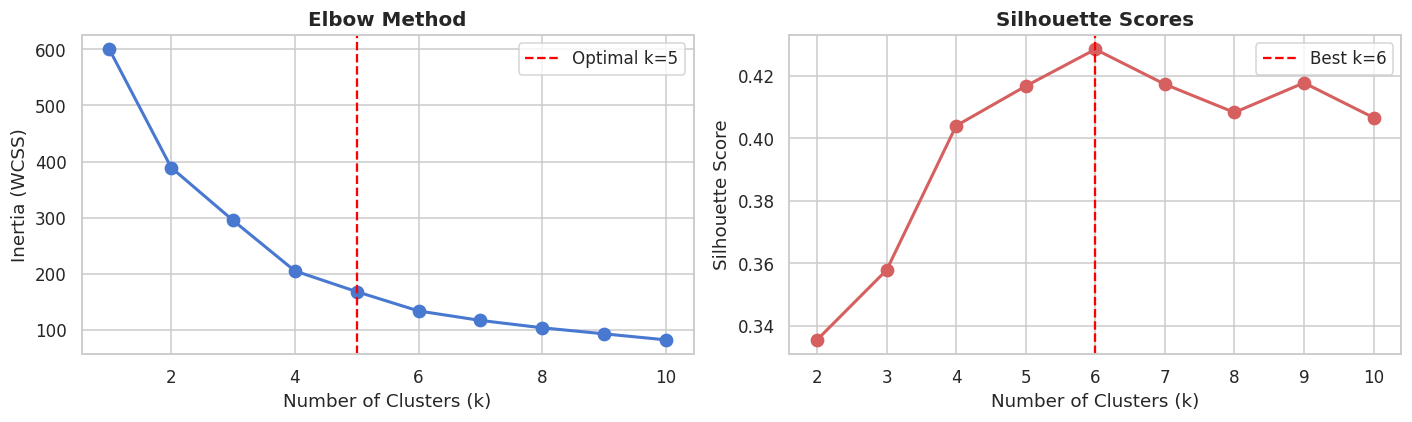

Best Silhouette Score: 0.4284 at k=6


In [11]:
# ── Prepare features for clustering ──────────────────────────────────────────
features = ['Age', 'Annual_Income', 'Spending_Score']
X = df[features].values

# Scale the features (K-Means is distance-based — scaling is important)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Elbow Method: plot inertia (WCSS) for k = 1 to 10 ─────────────────────────
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        sil = silhouette_score(X_scaled, km.labels_)
        silhouettes.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow curve
axes[0].plot(range(1, 11), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', label='Optimal k=5')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].legend()

# Silhouette scores
axes[1].plot(list(K_range), silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Scores', fontsize=13, fontweight='bold')
axes[1].axvline(x=silhouettes.index(max(silhouettes))+2, color='red',
                linestyle='--', label=f'Best k={silhouettes.index(max(silhouettes))+2}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Best Silhouette Score: {max(silhouettes):.4f} at k={silhouettes.index(max(silhouettes))+2}')

## Step 5: Apply K-Means Clustering (k=5)

In [12]:
# ── Final K-Means with k=5 ────────────────────────────────────────────────────
OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Final Silhouette Score (k={OPTIMAL_K}): {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print(f'\nCustomers per cluster:')
print(df['Cluster'].value_counts().sort_index())

# Cluster centroids (back in original scale)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_orig, columns=features)
centroids_df.index.name = 'Cluster'
print('\nCluster Centroids (original scale):')
print(centroids_df.round(1))

Final Silhouette Score (k=5): 0.4166

Customers per cluster:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

Cluster Centroids (original scale):
          Age  Annual_Income  Spending_Score
Cluster                                     
0        46.2           26.8            18.3
1        25.2           41.1            62.2
2        32.9           86.1            81.5
3        39.9           86.1            19.4
4        55.6           54.4            48.9


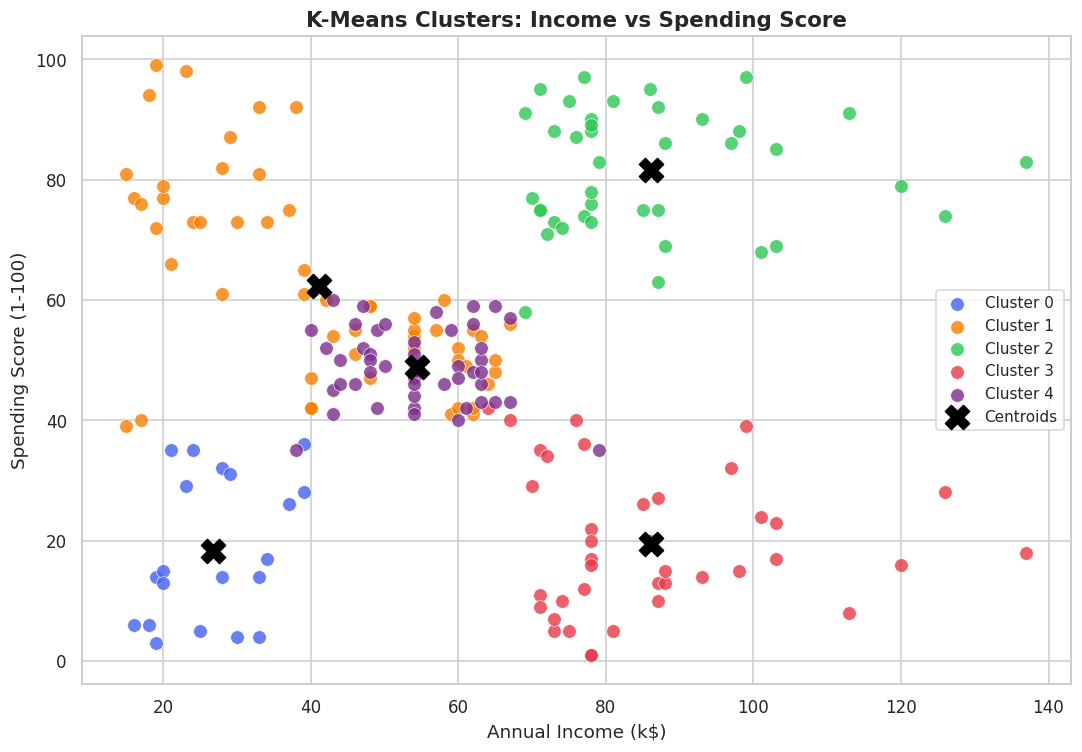

In [13]:
# ── Visualize clusters: Income vs Spending Score ──────────────────────────────
plt.figure(figsize=(10, 7))

for cluster in range(OPTIMAL_K):
    mask = df['Cluster'] == cluster
    plt.scatter(
        df.loc[mask, 'Annual_Income'],
        df.loc[mask, 'Spending_Score'],
        c=CLUSTER_COLORS[cluster], label=f'Cluster {cluster}',
        s=80, alpha=0.8, edgecolors='white', linewidths=0.5
    )

# Plot centroids
plt.scatter(centroids_df['Annual_Income'], centroids_df['Spending_Score'],
            c='black', marker='X', s=250, zorder=5, label='Centroids')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('K-Means Clusters: Income vs Spending Score', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 6: PCA Visualization

PCA Explained Variance: PC1=44.3%, PC2=33.3%, Total=77.6%


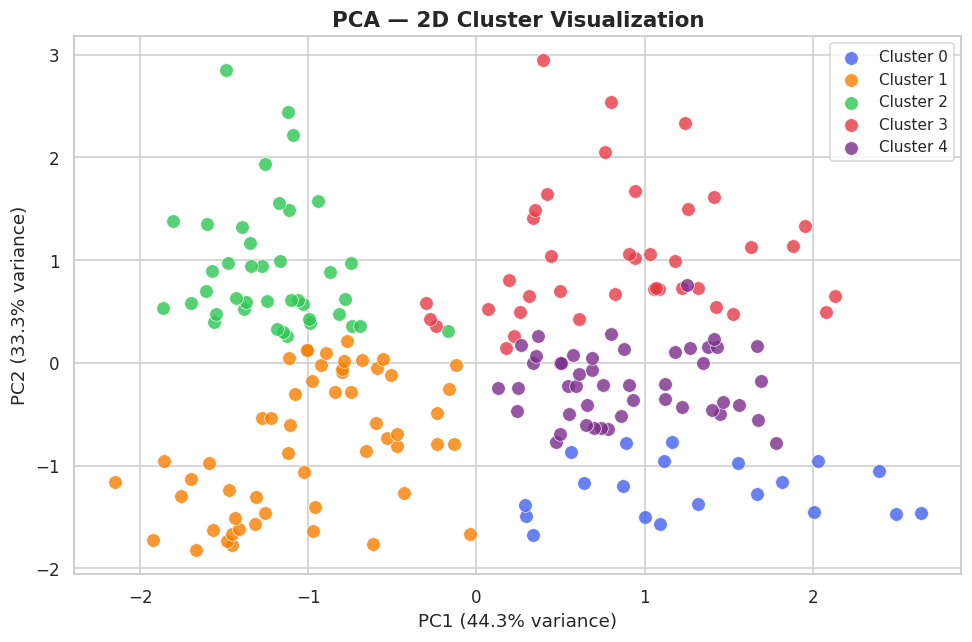

In [14]:
# ── PCA: reduce to 2D and visualize ──────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f'PCA Explained Variance: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%, Total={sum(explained):.1f}%')

plt.figure(figsize=(9, 6))
for cluster in range(OPTIMAL_K):
    mask = df['Cluster'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=CLUSTER_COLORS[cluster], label=f'Cluster {cluster}',
                s=80, alpha=0.8, edgecolors='white', linewidths=0.5)

plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=12)
plt.title('PCA — 2D Cluster Visualization', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 7: t-SNE Visualization

Running t-SNE (may take ~30 seconds)...


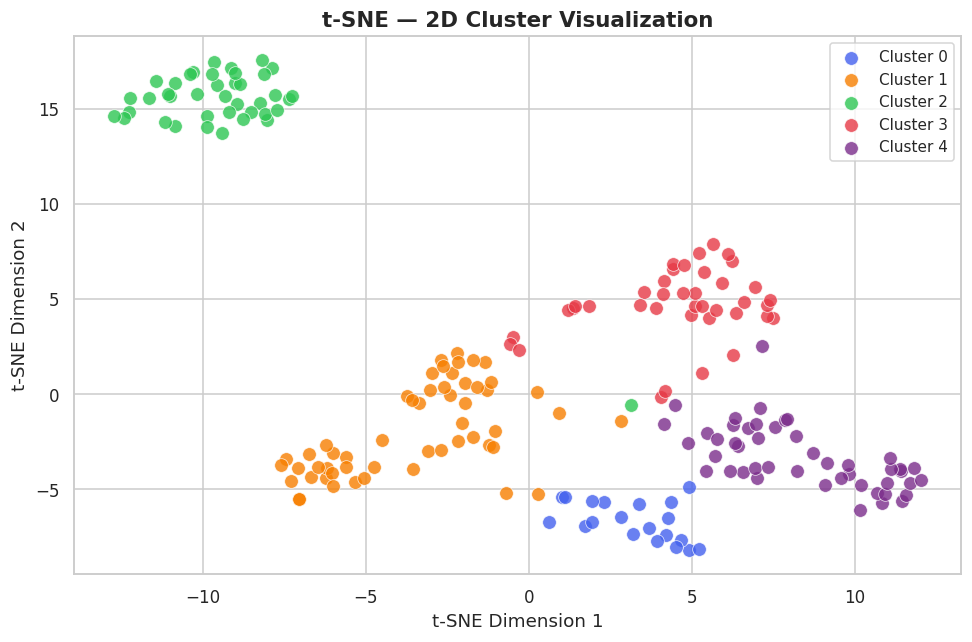

In [15]:
# ── t-SNE: better at preserving local cluster structure ───────────────────────
print('Running t-SNE (may take ~30 seconds)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
for cluster in range(OPTIMAL_K):
    mask = df['Cluster'] == cluster
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=CLUSTER_COLORS[cluster], label=f'Cluster {cluster}',
                s=80, alpha=0.8, edgecolors='white', linewidths=0.5)

plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('t-SNE — 2D Cluster Visualization', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 8: Cluster Profiling & Marketing Strategies

In [16]:
# ── Cluster-level statistics ──────────────────────────────────────────────────
profile = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
profile['Count'] = df['Cluster'].value_counts().sort_index()
print('Cluster Profiles:')
print(profile)

Cluster Profiles:
          Age  Annual_Income  Spending_Score  Count
Cluster                                            
0        46.2           26.8            18.4     20
1        25.2           41.1            62.2     54
2        32.9           86.1            81.5     40
3        39.9           86.1            19.4     39
4        55.6           54.4            48.9     47


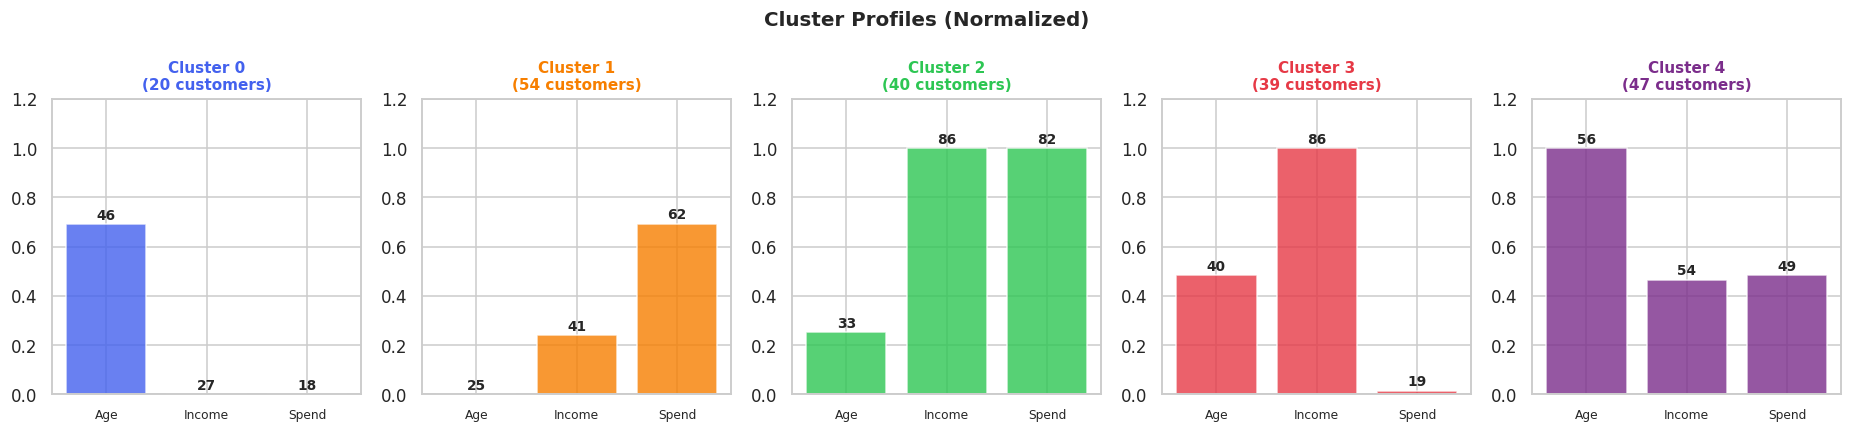

In [17]:
# ── Radar/Spider chart — compare clusters on all features ─────────────────────
from matplotlib.patches import FancyArrowPatch

features_radar = ['Age', 'Annual_Income', 'Spending_Score']
# Normalize to 0-1 for radar
radar_data = profile[features_radar].copy()
for col in features_radar:
    radar_data[col] = (radar_data[col] - radar_data[col].min()) / (radar_data[col].max() - radar_data[col].min())

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(17, 4))

for cluster in range(OPTIMAL_K):
    ax = axes[cluster]
    vals = radar_data.loc[cluster].values
    orig_vals = profile.loc[cluster]
    bars = ax.bar(features_radar, vals, color=CLUSTER_COLORS[cluster], alpha=0.8, edgecolor='white')
    ax.set_ylim(0, 1.2)
    ax.set_title(f'Cluster {cluster}\n({int(profile.loc[cluster,"Count"])} customers)',
                 fontsize=10, fontweight='bold', color=CLUSTER_COLORS[cluster])
    ax.set_xticklabels(['Age', 'Income', 'Spend'], fontsize=8)
    for bar, orig in zip(bars, [orig_vals['Age'], orig_vals['Annual_Income'], orig_vals['Spending_Score']]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{orig:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Cluster Profiles (Normalized)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ── Marketing Strategies for each segment ────────────────────────────────────

# Automatically label clusters based on income + spending
def label_cluster(row):
    inc = row['Annual_Income']
    sp  = row['Spending_Score']
    age = row['Age']
    if inc > 65 and sp > 65:
        return '💎 High-Value (Rich & Spender)'
    elif inc > 65 and sp < 40:
        return '💰 Cautious Rich (High Income, Low Spend)'
    elif inc < 40 and sp > 65:
        return '🛍️ Impulsive Spender (Low Income, High Spend)'
    elif inc < 40 and sp < 40:
        return '💸 Budget Shoppers (Low Income, Low Spend)'
    else:
        return '🎯 Average Customers (Middle Segment)'

profile['Segment Label'] = profile.apply(label_cluster, axis=1)

strategies = {
    '💎 High-Value (Rich & Spender)'        : 'Offer premium loyalty rewards, exclusive VIP events, personalized product recommendations, early access to new arrivals.',
    '💰 Cautious Rich (High Income, Low Spend)' : 'Target with high-quality, value-for-money messaging. Emphasize product durability and ROI. Send personalized discounts to trigger spending.',
    '🛍️ Impulsive Spender (Low Income, High Spend)' : 'Promote budget-friendly deals, EMI/installment options, flash sales. Use emotional marketing and FOMO tactics.',
    '💸 Budget Shoppers (Low Income, Low Spend)' : 'Focus on coupons, group discounts, and essential product bundles. Build trust through value-oriented campaigns.',
    '🎯 Average Customers (Middle Segment)' : 'Upsell with seasonal promotions, cross-sell complementary items, and send re-engagement campaigns with moderate discounts.',
}

print('='*70)
print('       CUSTOMER SEGMENTS & MARKETING STRATEGIES')
print('='*70)
for i, row in profile.iterrows():
    label = row['Segment Label']
    print(f'\nCluster {i}: {label}')
    print(f'  Avg Age: {row["Age"]:.0f} | Avg Income: ${row["Annual_Income"]:.0f}k | Avg Spend Score: {row["Spending_Score"]:.0f}')
    print(f'  Customers: {int(row["Count"])}')
    print(f'  Strategy: {strategies.get(label, "Analyze further")}')

       CUSTOMER SEGMENTS & MARKETING STRATEGIES

Cluster 0: 💸 Budget Shoppers (Low Income, Low Spend)
  Avg Age: 46 | Avg Income: $27k | Avg Spend Score: 18
  Customers: 20
  Strategy: Focus on coupons, group discounts, and essential product bundles. Build trust through value-oriented campaigns.

Cluster 1: 🎯 Average Customers (Middle Segment)
  Avg Age: 25 | Avg Income: $41k | Avg Spend Score: 62
  Customers: 54
  Strategy: Upsell with seasonal promotions, cross-sell complementary items, and send re-engagement campaigns with moderate discounts.

Cluster 2: 💎 High-Value (Rich & Spender)
  Avg Age: 33 | Avg Income: $86k | Avg Spend Score: 82
  Customers: 40
  Strategy: Offer premium loyalty rewards, exclusive VIP events, personalized product recommendations, early access to new arrivals.

Cluster 3: 💰 Cautious Rich (High Income, Low Spend)
  Avg Age: 40 | Avg Income: $86k | Avg Spend Score: 19
  Customers: 39
  Strategy: Target with high-quality, value-for-money messaging. Emphasize pro

## Step 9: Final Conclusion & Insights

In [19]:
print('='*60)
print('           FINAL INSIGHTS SUMMARY')
print('='*60)
print()
print(f'Total Customers Analyzed : {len(df)}')
print(f'Optimal Clusters Found   : {OPTIMAL_K}')
print(f'Silhouette Score         : {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print()
print('📌 Key Insights:')
print('  1. 5 distinct customer segments were identified based on')
print('     Age, Annual Income, and Spending Score.')
print('  2. The High-Value segment (high income + high spending)')
print('     should be prioritized for premium campaigns.')
print('  3. The Cautious Rich segment is a hidden opportunity —')
print('     they can afford more but are not spending.')
print('  4. PCA and t-SNE both confirmed clear cluster separation.')
print('  5. K-Means with k=5 gave the best silhouette score,')
print('     confirmed by both the elbow and silhouette methods.')

           FINAL INSIGHTS SUMMARY

Total Customers Analyzed : 200
Optimal Clusters Found   : 5
Silhouette Score         : 0.4166

📌 Key Insights:
  1. 5 distinct customer segments were identified based on
     Age, Annual Income, and Spending Score.
  2. The High-Value segment (high income + high spending)
     should be prioritized for premium campaigns.
  3. The Cautious Rich segment is a hidden opportunity —
     they can afford more but are not spending.
  4. PCA and t-SNE both confirmed clear cluster separation.
  5. K-Means with k=5 gave the best silhouette score,
     confirmed by both the elbow and silhouette methods.
